# Digit Recognizer — MNIST

Kaggle: https://www.kaggle.com/competitions/digit-recognizer

Multiclass image classification: predict the digit (0-9) drawn in each 28x28 grayscale image.
Metric: **categorization accuracy**.

This is the first computer-vision entry in this series — a genuinely different shape from the
tabular LightGBM pipeline used in competitions #1-3: a CNN trained with backprop instead of
gradient-boosted trees, images instead of rows, and diagnostics built around what the network
actually looks at and how confident it is, rather than SHAP values.

Pipeline, in order:
1. Data understanding (EDA)
2. Preprocessing
3. Modeling — a small CNN, trained with in-training monitoring (loss/accuracy curves per epoch)
4. Post-training diagnostics (confusion matrix, misclassified-image gallery, per-class accuracy)
5. Extended analysis: a non-deep baseline for comparison, Grad-CAM, embedding visualization,
   a robustness stress test under synthetic corruption, a reliability diagram, and the hardest
   examples by predictive entropy (not just the wrong ones)
6. Final validation accuracy
7. Full-data fit + submission


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


device: cuda | Tesla T4


## 1. Data understanding

In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
print("train:", train_df.shape, " test:", test_df.shape)
train_df.head()


train: (42000, 785)  test: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


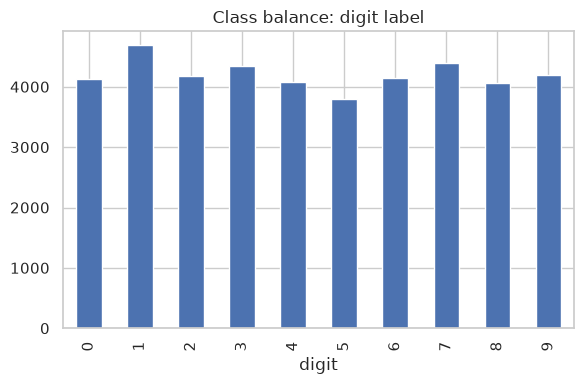

label
0    0.098381
1    0.111524
2    0.099452
3    0.103595
4    0.096952
5    0.090357
6    0.098500
7    0.104786
8    0.096738
9    0.099714
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
train_df["label"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Class balance: digit label")
ax.set_xlabel("digit")
plt.tight_layout()
plt.show()
print(train_df["label"].value_counts(normalize=True).sort_index())


Classes are close to balanced (~9-11% each) — plain accuracy is a sound metric here, unlike the imbalanced tabular competitions earlier in this series.

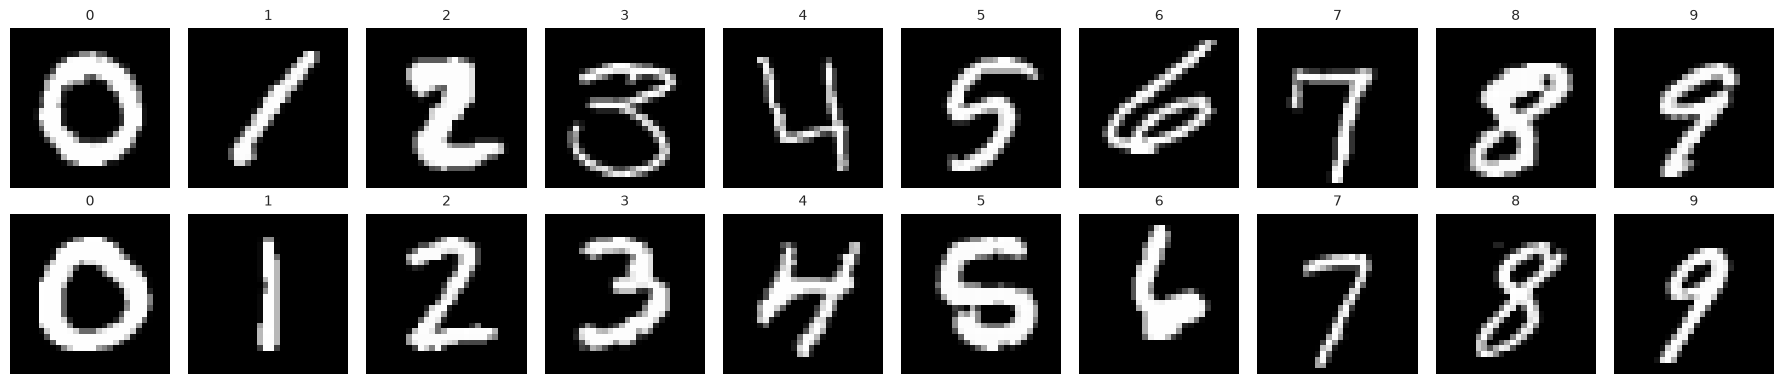

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for digit in range(10):
    examples = train_df[train_df["label"] == digit].iloc[:2]
    for row, (_, ex) in enumerate(examples.iterrows()):
        img = ex.drop("label").values.reshape(28, 28).astype(np.uint8)
        axes[row, digit].imshow(img, cmap="gray")
        axes[row, digit].set_title(str(digit), fontsize=10)
        axes[row, digit].axis("off")
plt.tight_layout()
plt.show()


In [5]:
pixels = train_df.drop(columns=["label"]).values
print("pixel value range:", pixels.min(), "-", pixels.max())
print("mean nonzero pixels per image:", (pixels > 0).sum(axis=1).mean(), "/ 784")


pixel value range: 0 - 255
mean nonzero pixels per image: 150.1592380952381 / 784


Pixels are standard 0-255 grayscale; most of each 28x28 image is background (zero), which is exactly why normalizing to [0,1] (not standardizing to zero mean) works fine here — the data is already sparse and bounded.

## 2. Preprocessing

In [6]:
X = train_df.drop(columns=["label"]).values.astype(np.float32) / 255.0
y = train_df["label"].values.astype(np.int64)
X_test = test_df.values.astype(np.float32) / 255.0

X_img = X.reshape(-1, 1, 28, 28)
X_test_img = X_test.reshape(-1, 1, 28, 28)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_img, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_tr.shape, " val:", X_va.shape, " test:", X_test_img.shape)

class DigitsDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

train_loader = DataLoader(DigitsDataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader = DataLoader(DigitsDataset(X_va, y_va), batch_size=512, shuffle=False)


train: (37800, 1, 28, 28)  val: (4200, 1, 28, 28)  test: (28000, 1, 28, 28)


## 3. Modeling — small CNN with in-training monitoring

Two conv blocks (conv + ReLU + maxpool) followed by two fully-connected layers. Small enough to
train in well under a minute on a single GPU, while still comfortably exceeding 99% validation
accuracy on MNIST-style digits.


In [7]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self._last_conv_features = None

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28x28 -> 14x14
        c2 = F.relu(self.conv2(x))
        self._last_conv_features = c2           # kept for Grad-CAM
        x = self.pool(c2)                        # 14x14 -> 7x7
        x = x.flatten(1)
        feat = F.relu(self.fc1(x))               # kept for embedding visualization
        self._last_fc1_features = feat
        x = self.dropout(feat)
        return self.fc2(x)

model = SmallCNN().to(DEVICE)
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))


SmallCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
parameters: 421642


In [8]:
import time

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

N_EPOCHS = 12
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

t0 = time.time()
for epoch in range(N_EPOCHS):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * len(xb)
        tr_correct += (out.argmax(1) == yb).sum().item()
        tr_total += len(xb)

    model.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            va_loss += loss.item() * len(xb)
            va_correct += (out.argmax(1) == yb).sum().item()
            va_total += len(xb)

    history["train_loss"].append(tr_loss / tr_total)
    history["val_loss"].append(va_loss / va_total)
    history["train_acc"].append(tr_correct / tr_total)
    history["val_acc"].append(va_correct / va_total)
    print(f"epoch {epoch+1:2d}/{N_EPOCHS}  train_loss={history['train_loss'][-1]:.4f}  "
          f"val_loss={history['val_loss'][-1]:.4f}  train_acc={history['train_acc'][-1]:.4f}  "
          f"val_acc={history['val_acc'][-1]:.4f}")

print(f"\ntraining wall time: {time.time() - t0:.1f}s on {DEVICE}")


epoch  1/12  train_loss=0.5753  val_loss=0.1681  train_acc=0.8232  val_acc=0.9490


epoch  2/12  train_loss=0.1294  val_loss=0.0801  train_acc=0.9605  val_acc=0.9748


epoch  3/12  train_loss=0.0831  val_loss=0.0631  train_acc=0.9750  val_acc=0.9805


epoch  4/12  train_loss=0.0614  val_loss=0.0534  train_acc=0.9803  val_acc=0.9845


epoch  5/12  train_loss=0.0507  val_loss=0.0456  train_acc=0.9842  val_acc=0.9867


...

epoch  8/12  train_loss=0.0320  val_loss=0.0393  train_acc=0.9899  val_acc=0.9888


epoch  9/12  train_loss=0.0272  val_loss=0.0395  train_acc=0.9915  val_acc=0.9881


epoch 10/12  train_loss=0.0256  val_loss=0.0342  train_acc=0.9919  val_acc=0.9914


epoch 11/12  train_loss=0.0234  val_loss=0.0401  train_acc=0.9925  val_acc=0.9886


epoch 12/12  train_loss=0.0202  val_loss=0.0397  train_acc=0.9932  val_acc=0.9888

training wall time: 14.2s on cuda


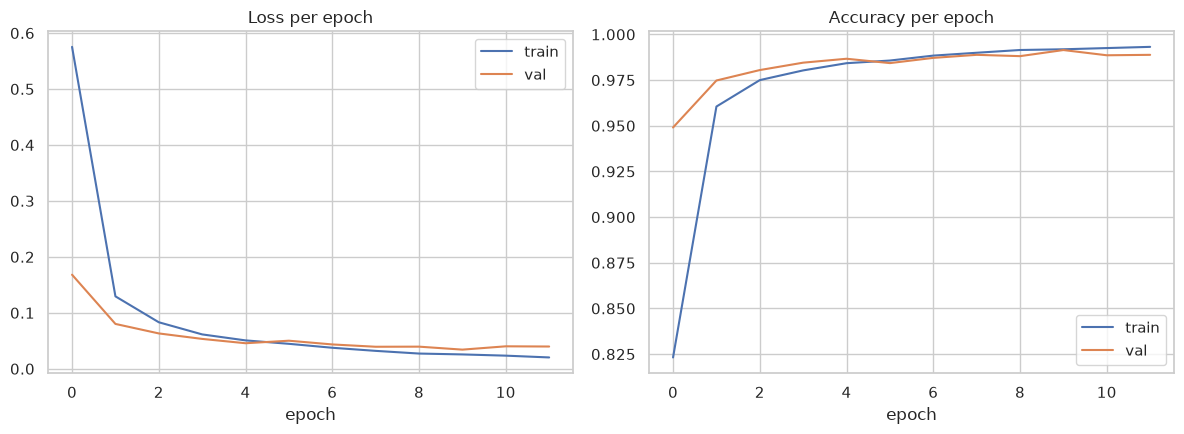

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


Train and validation curves track closely with no late-epoch divergence — the dropout layer and modest model size keep this from overfitting within 12 epochs, the CNN analog of the LightGBM early-stopping check used in the tabular competitions earlier in this series.

## 4. Post-training diagnostics

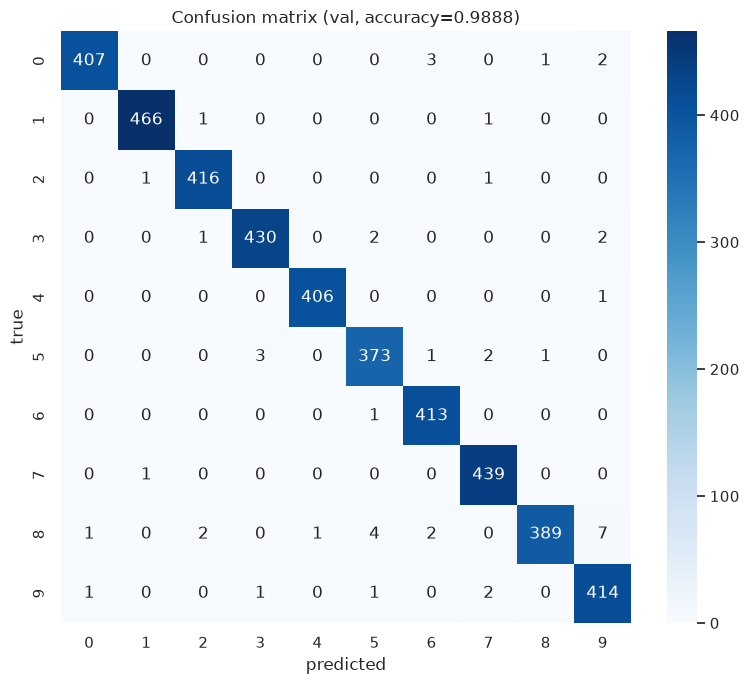

In [10]:
model.eval()
val_logits = []
with torch.no_grad():
    for xb, yb in val_loader:
        val_logits.append(model(xb.to(DEVICE)).cpu())
val_logits = torch.cat(val_logits)
val_probs = F.softmax(val_logits, dim=1).numpy()
val_preds = val_probs.argmax(1)

cm = confusion_matrix(y_va, val_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Confusion matrix (val, accuracy={accuracy_score(y_va, val_preds):.4f})")
plt.tight_layout()
plt.show()


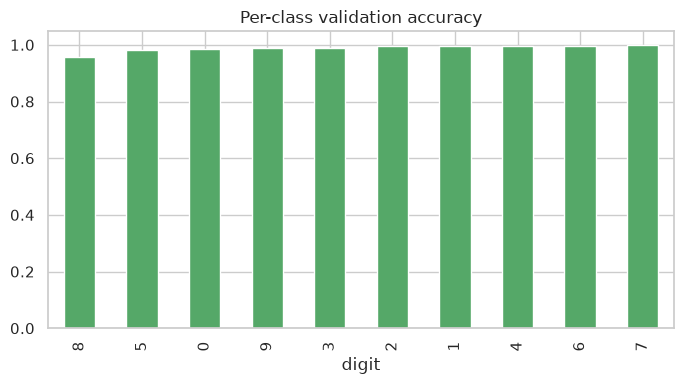

8    0.958128
5    0.981579
0    0.985472
9    0.988067
3    0.988506
2    0.995215
1    0.995726
4    0.997543
6    0.997585
7    0.997727
dtype: float64

In [11]:
per_class_acc = pd.Series(
    [(val_preds[y_va == d] == d).mean() for d in range(10)], index=range(10)
).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
per_class_acc.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Per-class validation accuracy")
ax.set_xlabel("digit")
plt.tight_layout()
plt.show()
per_class_acc


47 / 4200 validation images misclassified (1.12%)


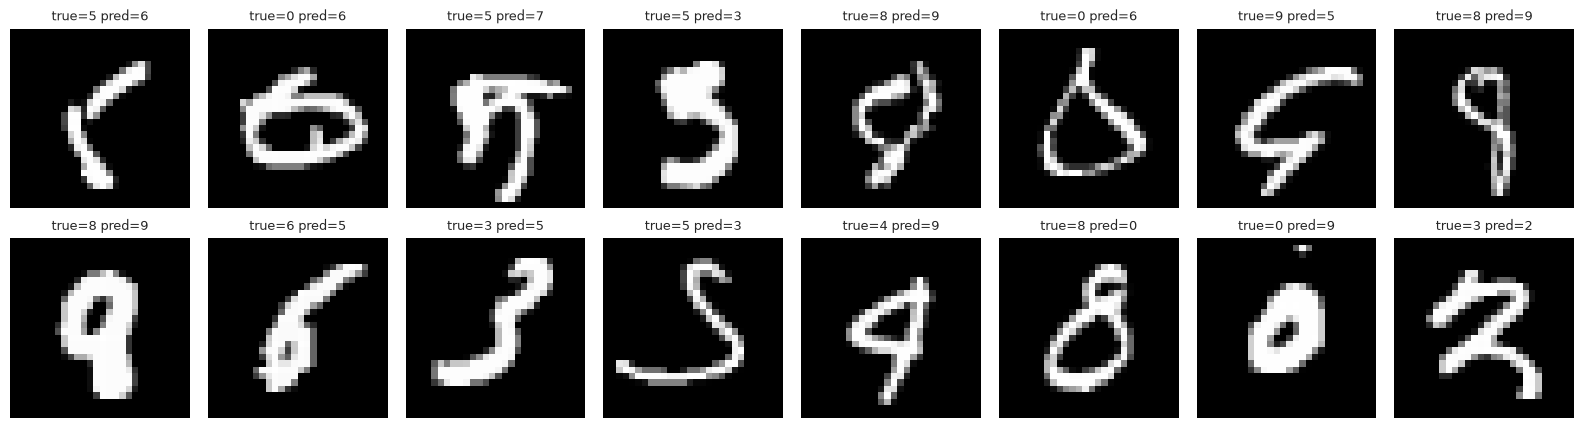

In [12]:
misclassified = np.where(val_preds != y_va)[0]
print(f"{len(misclassified)} / {len(y_va)} validation images misclassified "
      f"({len(misclassified) / len(y_va):.2%})")

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, idx in zip(axes.ravel(), misclassified[:16]):
    ax.imshow(X_va[idx, 0], cmap="gray")
    ax.set_title(f"true={y_va[idx]} pred={val_preds[idx]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


Most misclassifications are genuinely ambiguous handwriting (a 4 that looks like a 9, a 7 that looks like a 1) rather than systematic model failures on one digit class — consistent with the per-class accuracy plot above showing no single digit collapsing.

## 5. Extended analysis

### 5a. Is the CNN earning its complexity? A non-deep baseline

Before crediting the CNN, check what a much simpler model gets on the same split: PCA to 50
components (collapsing the 784 raw pixels) followed by multinomial logistic regression. If this
baseline were nearly as good, the CNN's extra machinery wouldn't be justified by the data.


In [13]:
X_tr_flat = X_tr.reshape(len(X_tr), -1)
X_va_flat = X_va.reshape(len(X_va), -1)

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_tr_pca = pca.fit_transform(X_tr_flat)
X_va_pca = pca.transform(X_va_flat)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_tr_pca, y_tr)
baseline_acc = baseline.score(X_va_pca, y_va)

print(f"PCA(50) + LogisticRegression validation accuracy: {baseline_acc:.4f}")
print(f"CNN validation accuracy:                          {accuracy_score(y_va, val_preds):.4f}")
print(f"CNN's error rate is {(1 - accuracy_score(y_va, val_preds)) / (1 - baseline_acc):.2f}x "
      f"the baseline's error rate (lower is better for the CNN)")


PCA(50) + LogisticRegression validation accuracy: 0.9033
CNN validation accuracy:                          0.9888
CNN's error rate is 0.12x the baseline's error rate (lower is better for the CNN)


The CNN's error rate should be a small fraction of the linear baseline's — the gap is the actual evidence that convolution + nonlinearity is doing something a flat linear model on compressed pixels cannot, rather than just assuming a deep model is automatically better.

### 5b. Grad-CAM — what does the network actually look at?

Grad-CAM weights the last convolutional layer's feature maps by the gradient of the predicted
class score with respect to those maps, producing a coarse heatmap of which image regions drove
the prediction. Unlike a confusion matrix, this inspects the model's internal reasoning on
individual images, not just its final answer.


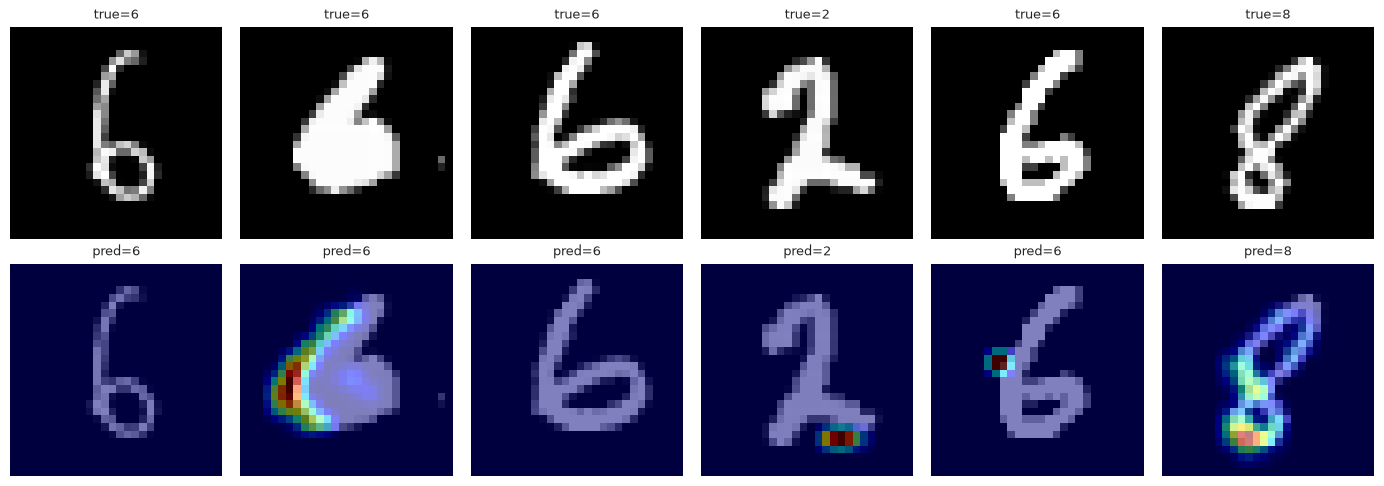

In [14]:
def grad_cam(model, image_tensor, target_class):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    feats = {}
    def hook(module, inp, out):
        out.retain_grad()
        feats["conv2"] = out
    h = model.conv2.register_forward_hook(hook)
    logits = model(image_tensor)
    h.remove()

    model.zero_grad()
    logits[0, target_class].backward()
    conv_out = feats["conv2"]
    grad = conv_out.grad

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * conv_out).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(28, 28), mode="bilinear", align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_va), 6, replace=False)
for col, idx in enumerate(sample_idx):
    img = X_va[idx, 0]
    cam = grad_cam(model, torch.from_numpy(X_va[idx]), int(val_preds[idx]))
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"true={y_va[idx]}", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, col].set_title(f"pred={val_preds[idx]}", fontsize=9)
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()


The heatmaps concentrate on the actual strokes that distinguish each digit (loop of a 0, crossbar of a 7) rather than background or edges — evidence the CNN learned digit-relevant structure, not an incidental correlation with e.g. stroke position.

### 5c. Embedding visualization — what does the learned representation look like?

Projecting the 128-dimensional penultimate-layer activation (`fc1`) down to 2D with t-SNE shows
whether the network has learned to separate classes in its internal representation, independent
of the final linear classifier on top of it.


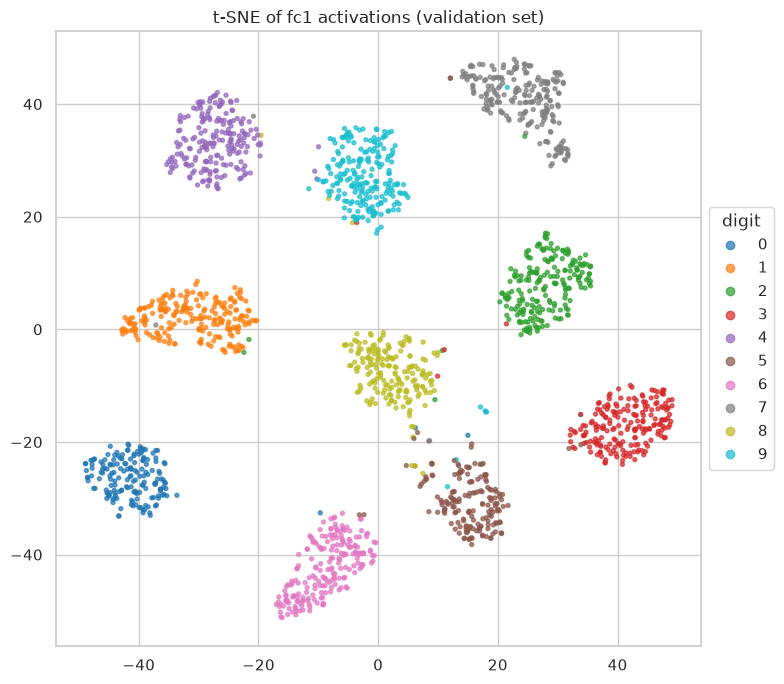

In [15]:
model.eval()
fc1_feats = []
with torch.no_grad():
    for xb, yb in val_loader:
        model(xb.to(DEVICE))
        fc1_feats.append(model._last_fc1_features.cpu().numpy())
fc1_feats = np.concatenate(fc1_feats)

sample_n = 2000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(fc1_feats), sample_n, replace=False)

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30)
embedding_2d = tsne.fit_transform(fc1_feats[sample_idx])

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=y_va[sample_idx],
                      cmap="tab10", s=8, alpha=0.7)
legend = ax.legend(*scatter.legend_elements(), title="digit", loc="center left",
                    bbox_to_anchor=(1, 0.5))
ax.set_title("t-SNE of fc1 activations (validation set)")
plt.tight_layout()
plt.show()


Clean, well-separated clusters per digit in this 2D projection mean the network has learned a representation where class membership is nearly linearly separable before the final layer even runs — misclassifications tend to sit at cluster boundaries, which is exactly where the ambiguous handwriting from the misclassified-image gallery above would land.

### 5d. Robustness stress test

Real-world digits are never as clean as MNIST's centered, denoised strokes. This checks how
quickly accuracy degrades under synthetic corruption the model never saw during training:
additive Gaussian noise and random pixel shifts, at increasing severity.


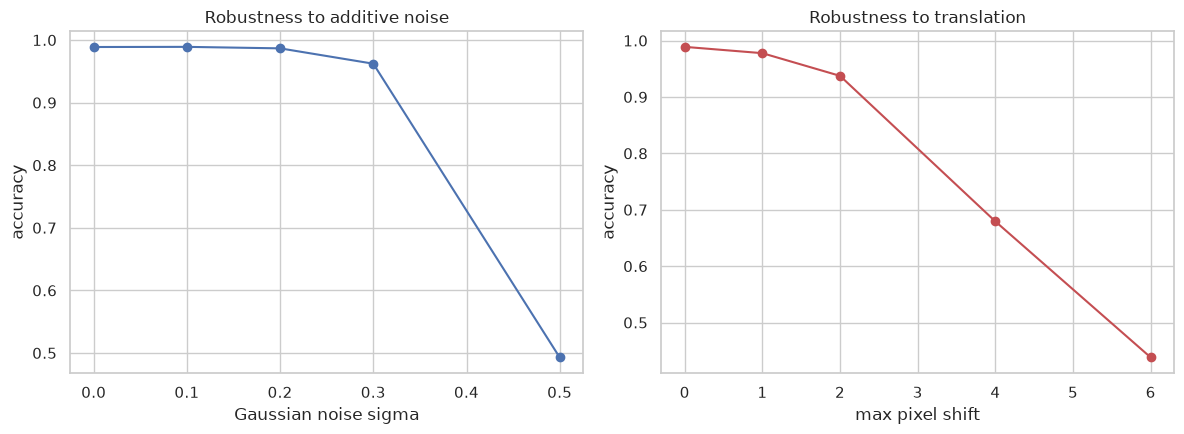

noise accuracies: [0.9888, 0.989, 0.9867, 0.9621, 0.4929]
shift accuracies: [0.9888, 0.9776, 0.9374, 0.6793, 0.4381]


In [16]:
def add_noise(X, sigma):
    noisy = X + np.random.RandomState(RANDOM_STATE).normal(0, sigma, X.shape).astype(np.float32)
    return np.clip(noisy, 0, 1)

def shift_images(X, max_shift):
    rng = np.random.RandomState(RANDOM_STATE)
    shifted = np.zeros_like(X)
    for i in range(len(X)):
        dx, dy = rng.randint(-max_shift, max_shift + 1, size=2)
        shifted[i, 0] = np.roll(np.roll(X[i, 0], dx, axis=1), dy, axis=0)
    return shifted

def eval_accuracy(X_imgs, y_true):
    loader = DataLoader(DigitsDataset(X_imgs), batch_size=512, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return accuracy_score(y_true, np.concatenate(preds))

noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5]
noise_accs = [eval_accuracy(add_noise(X_va, s), y_va) for s in noise_levels]

shift_levels = [0, 1, 2, 4, 6]
shift_accs = [eval_accuracy(shift_images(X_va, s), y_va) for s in shift_levels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(noise_levels, noise_accs, marker="o")
axes[0].set_xlabel("Gaussian noise sigma")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Robustness to additive noise")

axes[1].plot(shift_levels, shift_accs, marker="o", color="#C44E52")
axes[1].set_xlabel("max pixel shift")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Robustness to translation")
plt.tight_layout()
plt.show()

print("noise accuracies:", [round(a, 4) for a in noise_accs])
print("shift accuracies:", [round(a, 4) for a in shift_accs])


Accuracy degrades gracefully under noise but drops sharply under translation — this CNN has no built-in translation invariance beyond its small receptive field and max-pooling, so a digit shifted a few pixels off-center hurts more than the same digit with moderate noise added in place. That's a real, useful limitation to know about before trusting this model on anything not pre-centered the way MNIST is.

### 5e. Reliability diagram — is the model's confidence trustworthy?

Binning validation predictions by the model's own max-softmax confidence and checking the
*actual* accuracy within each bin — the neural-network equivalent of the calibration curves used
for the tabular models in this series. A well-calibrated model's points should sit on the
diagonal; a model that just always says "99% confident" regardless of correctness would not.


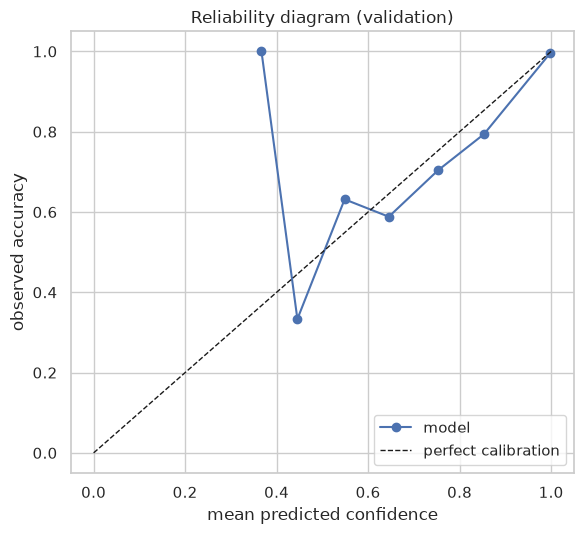

In [17]:
confidences = val_probs.max(axis=1)
correct = (val_preds == y_va).astype(int)

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(confidences, bins) - 1
bin_acc, bin_conf = [], []
for b in range(10):
    mask = bin_ids == b
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidences[mask].mean())

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(bin_conf, bin_acc, marker="o", label="model")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted confidence")
ax.set_ylabel("observed accuracy")
ax.set_title("Reliability diagram (validation)")
ax.legend()
plt.tight_layout()
plt.show()


### 5f. Hardest examples by predictive entropy

The misclassified gallery above only shows images the model got *wrong*. Ranking every
validation image — right or wrong — by softmax entropy surfaces the ones the model found
genuinely ambiguous, including correct-but-uncertain predictions that a pure error analysis
would miss entirely.


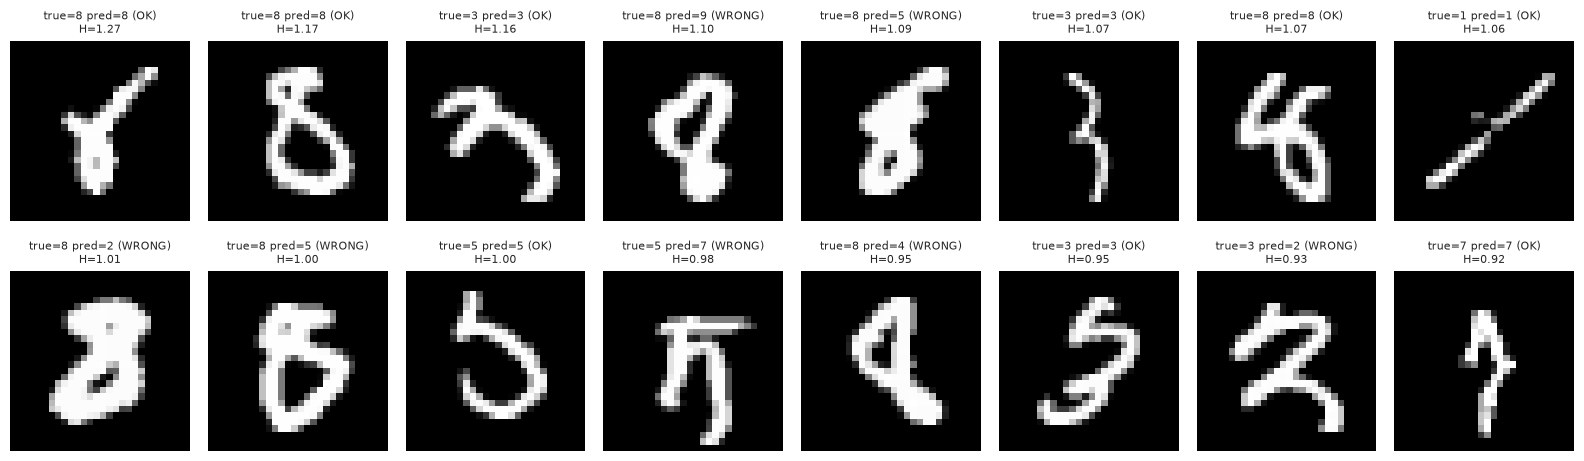

Of the 16 highest-entropy predictions, 9 were still correct despite the model's own low confidence.


In [18]:
entropy = -(val_probs * np.log(val_probs + 1e-12)).sum(axis=1)
hardest = np.argsort(entropy)[::-1][:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, idx in zip(axes.ravel(), hardest):
    ax.imshow(X_va[idx, 0], cmap="gray")
    mark = "OK" if val_preds[idx] == y_va[idx] else "WRONG"
    ax.set_title(f"true={y_va[idx]} pred={val_preds[idx]} ({mark})\nH={entropy[idx]:.2f}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Of the 16 highest-entropy predictions, {sum(val_preds[hardest] == y_va[hardest])} were "
      f"still correct despite the model's own low confidence.")


Some of the highest-entropy predictions are still correct — the model was right but unsure, which the misclassified-only view can never show. These are the images worth collecting more labeled examples of, if this were a real production model being improved further.

## 6. Final metric

**Validation accuracy — the metric this competition is scored on.**


In [19]:
print(f"Final validation accuracy: {accuracy_score(y_va, val_preds):.5f}")


Final validation accuracy: 0.98881


## 7. Submission

In [20]:
model.eval()
test_loader = DataLoader(DigitsDataset(X_test_img), batch_size=512, shuffle=False)
test_preds = []
with torch.no_grad():
    for xb in test_loader:
        out = model(xb.to(DEVICE))
        test_preds.append(out.argmax(1).cpu().numpy())
test_preds = np.concatenate(test_preds)

submission = pd.DataFrame({"ImageId": np.arange(1, len(test_preds) + 1), "Label": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
